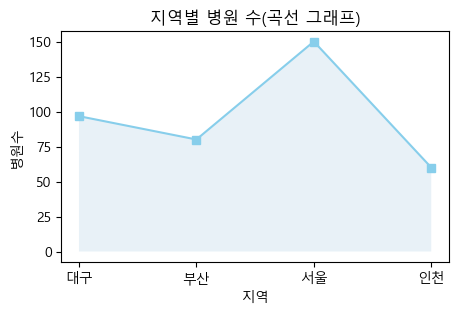

In [16]:
#반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리 불러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline



#데이터 생성하기
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

#데이터 전처리를 위해 merge(명함)을 진행한다.
#outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1,df2,on="지역",how="outer")

#결측치 처리를 진행한다.
#결측치는 병원수와, 총인구의 평균으로 정의한다.
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
#merged

#-------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x,y)
#-------------------------------------
#-------------------------------------
# 반드시 한글 깨짐 현상 코드를 삽입한다.
#-------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5,3))
#꺾은선 그래프 출력
plt.plot(merged["지역"], merged["병원수"],marker='s', color='skyblue')

#꺾은선 영역 그래프
#fill_between(x,y) => x축 기준으로 선아래를 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1:거의 투명, 0.3: 적당, 1~: 아주진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# x를 숫자로 변환하기
x = np.arange(len(merged['지역']))
y = merged['병원수']
smooth = np.linspace(x.min(), x.max(), 300)
smooth02 = make_interp_spline(x,y)(smooth)
#곡선그래프 출력
#plt.plot(smooth,smooth02)

# 차트제목, 가로축 제목, 세로축 제목 저장
plt.title("지역별 병원 수(곡선 그래프)")
plt.xlabel("지역")
plt.ylabel("병원수")


plt.show()

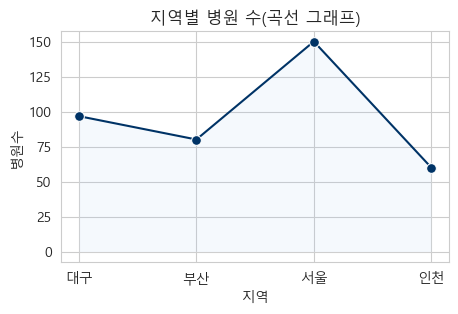

In [6]:
#반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리 불러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline
# seaborn: matplotlib 기반위에서 차트 이쁘게 꾸미는 도구
import seaborn as sns



#데이터 생성하기
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

#데이터 전처리를 위해 merge(명함)을 진행한다.
#outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1,df2,on="지역",how="outer")

#결측치 처리를 진행한다.
#결측치는 병원수와, 총인구의 평균으로 정의한다.
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
#merged

#seaborn 스타일 지정
sns.set_style('whitegrid') # 배경스타일 설정, dark : 그리드 없이 어두운 배경 지정
sns.set_palette('pastel') # 색상 스타일 지정, deep : 진하게

#-------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x,y)
#-------------------------------------
#-------------------------------------
# 반드시 한글 깨짐 현상 코드를 삽입한다.
#-------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5,3))
#꺾은선 그래프 출력
#plt.plot(merged["지역"], merged["병원수"],marker='s', color='skyblue')
ax=sns.lineplot(x='지역',y='병원수',data=merged,marker='o',markersize=7,color='#003366')

#꺾은선 영역 그래프
#fill_between(x,y) => x축 기준으로 선아래를 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1:거의 투명, 0.3: 적당, 1~: 아주진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# x를 숫자로 변환하기
x = np.arange(len(merged['지역']))
y = merged['병원수']
smooth = np.linspace(x.min(), x.max(), 300)
smooth02 = make_interp_spline(x,y)(smooth)
#곡선그래프 출력
#plt.plot(smooth,smooth02)

# 차트제목, 가로축 제목, 세로축 제목 저장
plt.title("지역별 병원 수(곡선 그래프)")
plt.xlabel("지역")
plt.ylabel("병원수")


plt.show()